# Sim2Real Transition Domain Randomization Comparison

This notebook compares two travel-time series for the sim2real transition experiments:

- Direct transfer from the structured DTL logs in `raw_results/sim2real_transitions/cityflow_presslight`
- Domain-randomization `Real rollout` results from `data/output_data/sim2real_transitions/cityflow_presslight`

Assumptions used here:

- Direct transfer matches the logic in `analyze_dtl_tables.ipynb`: `Real rollout` at `epoch == 0`
- DR uses the latest available DTL log per network and setting that contains a `Real rollout` entry
- Missing DR bars are left blank instead of being filled with synthetic values

In [1]:
from datetime import datetime
from pathlib import Path

from IPython.display import Markdown, display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASELINE_ROOT = Path("raw_results/sim2real_transitions/cityflow_presslight")
DR_ROOT = Path("data/output_data/sim2real_transitions/cityflow_presslight")

NETWORK_ORDER = [
    "bullhead_1",
    "bullhead_3",
    "cologne1",
    "cologne3",
    "hz1x1",
    "ingolstadt1",
    "ingolstadt7",
    "tempe_16",
    "tempe_1x1",
]

SETTING_ORDER = [4]
SETTING_LABELS = [f"Setting {setting}" for setting in SETTING_ORDER]
BASELINE_MODEL_ORDER = ["gat", "ugat", "jlgat"]
KNOWN_TRANSITION_MODELS = ["domain_randomization", "jlgat", "ugat", "gat"]
COLUMNS = [
    "exp_name",
    "mode",
    "epoch",
    "travel_time",
    "ignore",
    "reward",
    "queue",
    "delay",
    "throughput",
]


In [2]:
def parse_exp_name(exp_name: str) -> dict:
    if "_setting" not in exp_name:
        raise ValueError(f"Unsupported experiment name: {exp_name}")

    network, remainder = exp_name.split("_setting", 1)
    setting_str, remainder = remainder.split("_", 1)

    transition_model = None
    tsc_model = None
    for candidate in KNOWN_TRANSITION_MODELS:
        suffix = f"_{candidate}"
        if remainder.endswith(suffix):
            transition_model = candidate
            tsc_model = remainder[: -len(suffix)]
            break

    if transition_model is None or not tsc_model:
        raise ValueError(f"Unsupported experiment name: {exp_name}")
    return {
        "network": network,
        "setting": int(setting_str),
        "setting_label": f"Setting {int(setting_str)}",
        "tsc_model": tsc_model,
        "transition_model": transition_model,
    }


def parse_log_timestamp(log_path: Path) -> datetime:
    return datetime.strptime(log_path.stem.replace("_DTL", ""), "%Y_%m_%d-%H_%M_%S")


def read_dtl_log(log_path: Path) -> tuple[dict, pd.DataFrame]:
    df = pd.read_csv(log_path, sep="\t", header=None, names=COLUMNS)
    exp_name = str(df.iloc[0]["exp_name"])
    info = parse_exp_name(exp_name)
    info["exp_name"] = exp_name
    info["log_path"] = log_path
    info["timestamp"] = parse_log_timestamp(log_path)
    return info, df


def real_rollout_epoch0(df: pd.DataFrame) -> float:
    real_rows = df[df["mode"] == "Real rollout"]
    epoch0 = real_rows[real_rows["epoch"] == 0]
    if epoch0.empty:
        return np.nan
    return float(epoch0.iloc[0]["travel_time"])


def sim_rollout_epoch0(df: pd.DataFrame) -> float:
    sim_rows = df[df["mode"] == "Sim Rollout"]
    epoch0 = sim_rows[sim_rows["epoch"] == 0]
    if epoch0.empty:
        return np.nan
    return float(epoch0.iloc[0]["travel_time"])


def best_real_rollout(df: pd.DataFrame) -> float:
    real_rows = df[df["mode"] == "Real rollout"]
    if real_rows.empty:
        return np.nan
    return float(real_rows["travel_time"].min())


def load_direct_transfer() -> pd.DataFrame:
    rows = []
    for log_path in sorted(BASELINE_ROOT.glob("*/test/logger/*_DTL.log")):
        try:
            info, df = read_dtl_log(log_path)
        except ValueError:
            continue
        if info["network"] not in NETWORK_ORDER:
            continue
        if info["setting"] not in SETTING_ORDER:
            continue
        if info["transition_model"] not in BASELINE_MODEL_ORDER:
            continue
        cityflow_epoch0 = sim_rollout_epoch0(df)
        direct_transfer = real_rollout_epoch0(df)
        rows.append({
            **info,
            "cityflow_epoch0": cityflow_epoch0,
            "direct_transfer": direct_transfer,
            "direct_gap": direct_transfer - cityflow_epoch0,
            "baseline_model_rank": BASELINE_MODEL_ORDER.index(info["transition_model"]),
        })

    baseline_columns = [
        "network",
        "setting",
        "setting_label",
        "tsc_model",
        "transition_model",
        "exp_name",
        "log_path",
        "timestamp",
        "cityflow_epoch0",
        "direct_transfer",
        "direct_gap",
        "baseline_model_rank",
    ]
    baseline_df = pd.DataFrame(rows, columns=baseline_columns)
    if baseline_df.empty:
        return baseline_df
    baseline_df = baseline_df.sort_values(
        ["network", "setting", "baseline_model_rank", "timestamp"]
    )
    baseline_df = baseline_df.drop_duplicates(["network", "setting"], keep="first")
    return baseline_df.reset_index(drop=True)


def load_domain_randomization() -> pd.DataFrame:
    rows = []
    for log_path in sorted(DR_ROOT.glob("*/test/logger/*_DTL.log")):
        try:
            info, df = read_dtl_log(log_path)
        except ValueError:
            continue
        if info["network"] not in NETWORK_ORDER:
            continue
        if info["setting"] not in SETTING_ORDER:
            continue
        if info["transition_model"] != "domain_randomization":
            continue

        cityflow_epoch0 = sim_rollout_epoch0(df)
        dr_value = best_real_rollout(df)
        if np.isnan(dr_value):
            continue

        rows.append({
            **info,
            "cityflow_epoch0": cityflow_epoch0,
            "dr_real_rollout": dr_value,
            "dr_gap": dr_value - cityflow_epoch0,
        })

    dr_columns = [
        "network",
        "setting",
        "setting_label",
        "tsc_model",
        "transition_model",
        "exp_name",
        "log_path",
        "timestamp",
        "cityflow_epoch0",
        "dr_real_rollout",
        "dr_gap",
    ]
    dr_df = pd.DataFrame(rows, columns=dr_columns)
    if dr_df.empty:
        return dr_df
    dr_df = dr_df.sort_values(["network", "setting", "timestamp"])
    dr_df = dr_df.drop_duplicates(["network", "setting"], keep="last")
    return dr_df.reset_index(drop=True)


In [3]:
baseline_df = load_direct_transfer()
dr_df = load_domain_randomization()

comparison_df = pd.merge(
    baseline_df[
        [
            "network",
            "setting",
            "setting_label",
            "cityflow_epoch0",
            "direct_transfer",
            "direct_gap",
            "log_path",
            "transition_model",
        ]
    ].rename(
        columns={
            "cityflow_epoch0": "direct_cityflow_epoch0",
            "log_path": "direct_log_path",
            "transition_model": "direct_source_model",
        }
    ),
    dr_df[
        [
            "network",
            "setting",
            "cityflow_epoch0",
            "dr_real_rollout",
            "dr_gap",
            "log_path",
        ]
    ].rename(columns={"cityflow_epoch0": "dr_cityflow_epoch0", "log_path": "dr_log_path"}),
    on=["network", "setting"],
    how="outer",
)

comparison_df["setting_label"] = comparison_df["setting"].map(lambda value: f"Setting {int(value)}")
comparison_df["network"] = pd.Categorical(comparison_df["network"], categories=NETWORK_ORDER, ordered=True)
comparison_df = comparison_df.sort_values(["setting", "network"]).reset_index(drop=True)

display(Markdown("## Coverage"))
coverage_df = comparison_df[["network", "setting_label", "direct_transfer", "dr_real_rollout"]].copy()
coverage_df["direct_transfer"] = coverage_df["direct_transfer"].notna().map({True: "yes", False: ""})
coverage_df["dr_real_rollout"] = coverage_df["dr_real_rollout"].notna().map({True: "yes", False: ""})
display(
    coverage_df.rename(
        columns={
            "setting_label": "setting",
            "direct_transfer": "direct transfer",
            "dr_real_rollout": "DR Real Rollout",
        }
    ).style.hide(axis="index")
)

print(f"Direct-transfer rows: {len(baseline_df)}")
print(f"Domain-randomization rows: {len(dr_df)}")


## Coverage

network,setting,direct transfer,DR Real Rollout
bullhead_1,Setting 4,yes,yes
bullhead_3,Setting 4,yes,yes
cologne1,Setting 4,yes,yes
cologne3,Setting 4,yes,yes
hz1x1,Setting 4,yes,yes
ingolstadt1,Setting 4,yes,yes
ingolstadt7,Setting 4,yes,yes
tempe_16,Setting 4,yes,yes
tempe_1x1,Setting 4,yes,yes


Direct-transfer rows: 9
Domain-randomization rows: 9


In [4]:
direct_table = comparison_df.pivot(index="setting_label", columns="network", values="direct_gap")
direct_table = direct_table.reindex(index=SETTING_LABELS)
direct_table = direct_table.reindex(columns=NETWORK_ORDER)

dr_table = comparison_df.pivot(index="setting_label", columns="network", values="dr_gap")
dr_table = dr_table.reindex(index=SETTING_LABELS)
dr_table = dr_table.reindex(columns=NETWORK_ORDER)

display(Markdown("## Direct Transfer Gap Table"))
display(direct_table.style.format("{:.1f}"))

display(Markdown("## DR Real Rollout Gap Table"))
display(dr_table.style.format("{:.1f}"))

display(Markdown("## Log Sources"))
log_table = comparison_df[[
    "network",
    "setting_label",
    "direct_source_model",
    "direct_log_path",
    "dr_log_path",
]].copy()
display(log_table.style.hide(axis="index"))


## Direct Transfer Gap Table

network,bullhead_1,bullhead_3,cologne1,cologne3,hz1x1,ingolstadt1,ingolstadt7,tempe_16,tempe_1x1
setting_label,,,,,,,,,
Setting 4,31.3,727.0,167.2,297.7,134.9,78.1,180.9,85.7,412.1


## DR Real Rollout Gap Table

network,bullhead_1,bullhead_3,cologne1,cologne3,hz1x1,ingolstadt1,ingolstadt7,tempe_16,tempe_1x1
setting_label,,,,,,,,,
Setting 4,-188.0,-276.1,-71.7,-539.3,-597.1,21.5,21.5,-152.6,15.6


## Log Sources

network,setting_label,direct_source_model,direct_log_path,dr_log_path
bullhead_1,Setting 4,gat,raw_results/sim2real_transitions/cityflow_presslight/bullhead_1/test/logger/2026_03_27-11_31_21_DTL.log,data/output_data/sim2real_transitions/cityflow_presslight/bullhead_1/test/logger/2026_04_10-00_40_39_DTL.log
bullhead_3,Setting 4,gat,raw_results/sim2real_transitions/cityflow_presslight/bullhead_3/test/logger/2026_03_28-16_41_18_DTL.log,data/output_data/sim2real_transitions/cityflow_presslight/bullhead_3/test/logger/2026_04_10-09_58_23_DTL.log
cologne1,Setting 4,gat,raw_results/sim2real_transitions/cityflow_presslight/cologne1/test/logger/2026_03_27-13_17_59_DTL.log,data/output_data/sim2real_transitions/cityflow_presslight/cologne1/test/logger/2026_04_10-01_25_13_DTL.log
cologne3,Setting 4,gat,raw_results/sim2real_transitions/cityflow_presslight/cologne3/test/logger/2026_03_28-22_08_56_DTL.log,data/output_data/sim2real_transitions/cityflow_presslight/cologne3/test/logger/2026_04_10-11_55_42_DTL.log
hz1x1,Setting 4,gat,raw_results/sim2real_transitions/cityflow_presslight/hz1x1/test/logger/2026_03_27-15_09_31_DTL.log,data/output_data/sim2real_transitions/cityflow_presslight/hz1x1/test/logger/2026_04_10-02_53_36_DTL.log
ingolstadt1,Setting 4,gat,raw_results/sim2real_transitions/cityflow_presslight/ingolstadt1/test/logger/2026_03_27-14_09_07_DTL.log,data/output_data/sim2real_transitions/cityflow_presslight/ingolstadt1/test/logger/2026_04_10-02_09_23_DTL.log
ingolstadt7,Setting 4,gat,raw_results/sim2real_transitions/cityflow_presslight/ingolstadt7/test/logger/2026_03_29-06_22_15_DTL.log,data/output_data/sim2real_transitions/cityflow_presslight/ingolstadt7/test/logger/2026_04_10-13_41_17_DTL.log
tempe_16,Setting 4,gat,raw_results/sim2real_transitions/cityflow_presslight/tempe_16/test/logger/2026_03_29-00_53_29_DTL.log,data/output_data/sim2real_transitions/cityflow_presslight/tempe_16/test/logger/2026_04_10-03_39_03_DTL.log
tempe_1x1,Setting 4,gat,raw_results/sim2real_transitions/cityflow_presslight/tempe_1x1/test/logger/2026_03_27-11_49_52_DTL.log,data/output_data/sim2real_transitions/cityflow_presslight/tempe_1x1/test/logger/2026_04_09-23_52_15_DTL.log


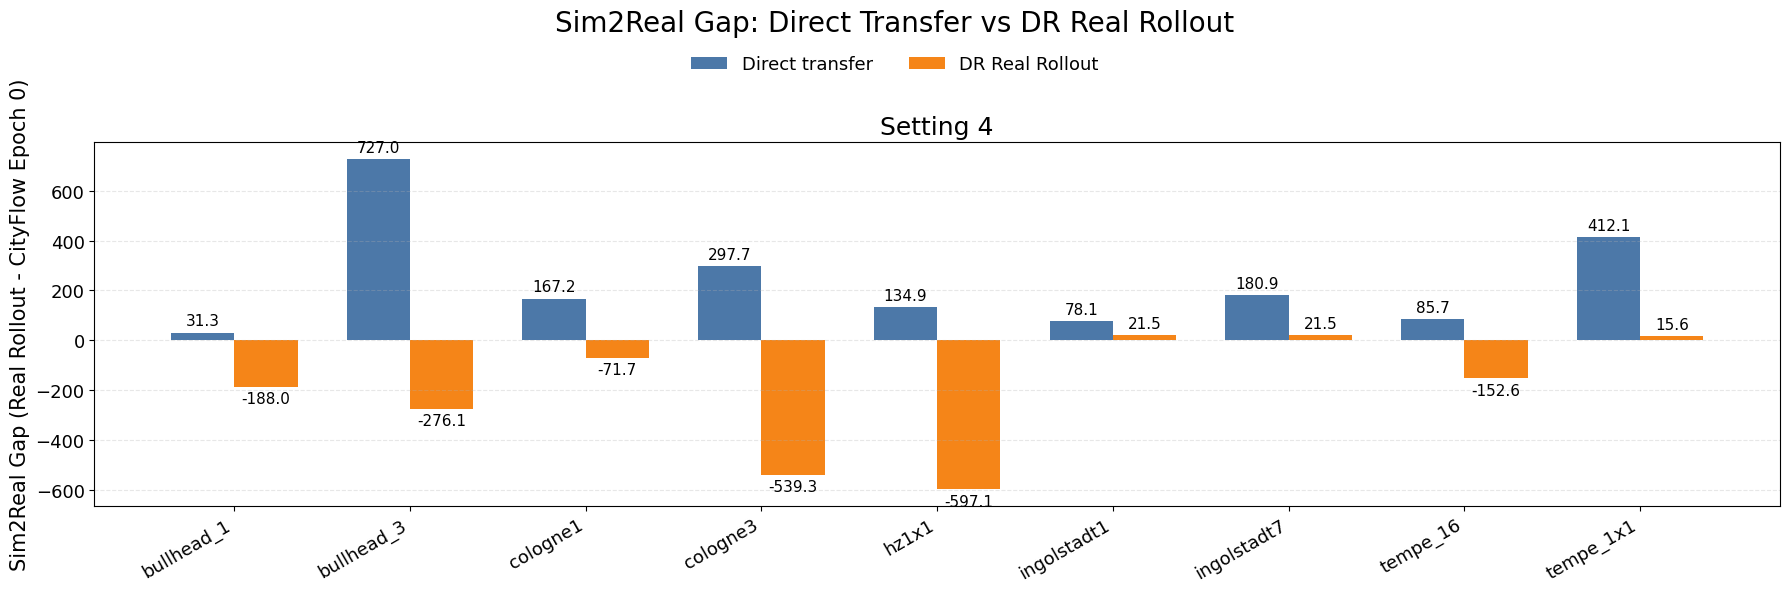

In [5]:
BAR_COLORS = {
    "Direct transfer": "#4C78A8",
    "DR Real Rollout": "#F58518",
}

TITLE_SIZE = 18
AXIS_LABEL_SIZE = 15
TICK_LABEL_SIZE = 13
LEGEND_SIZE = 13
BAR_LABEL_SIZE = 11

fig, ax = plt.subplots(figsize=(18, 6))
x = np.arange(len(NETWORK_ORDER))
width = 0.36

setting = SETTING_ORDER[0]
setting_label = f"Setting {setting}"
subset = comparison_df[comparison_df["setting"] == setting].copy()
subset = subset.set_index("network").reindex(NETWORK_ORDER)

direct_values = subset["direct_gap"].to_numpy(dtype=float)
dr_values = subset["dr_gap"].to_numpy(dtype=float)

direct_bars = ax.bar(
    x - width / 2,
    direct_values,
    width=width,
    color=BAR_COLORS["Direct transfer"],
    label="Direct transfer",
)
dr_bars = ax.bar(
    x + width / 2,
    dr_values,
    width=width,
    color=BAR_COLORS["DR Real Rollout"],
    label="DR Real Rollout",
)

direct_labels = [f"{value:.1f}" if np.isfinite(value) else "" for value in direct_values]
dr_labels = [f"{value:.1f}" if np.isfinite(value) else "" for value in dr_values]
ax.bar_label(direct_bars, labels=direct_labels, padding=3, fontsize=BAR_LABEL_SIZE)
ax.bar_label(dr_bars, labels=dr_labels, padding=3, fontsize=BAR_LABEL_SIZE)
ax.set_title(setting_label, fontsize=TITLE_SIZE)
ax.set_xticks(x)
ax.set_xticklabels(NETWORK_ORDER, rotation=30, ha="right", fontsize=TICK_LABEL_SIZE)
ax.tick_params(axis="y", labelsize=TICK_LABEL_SIZE)
ax.grid(axis="y", linestyle="--", alpha=0.3)

if np.isnan(dr_values).all():
    ax.text(0.5, 0.9, "No DR Real Rollout logs found", ha="center", va="center", transform=ax.transAxes)

ax.set_ylabel("Sim2Real Gap (Real Rollout - CityFlow Epoch 0)", fontsize=AXIS_LABEL_SIZE)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=2, frameon=False, fontsize=LEGEND_SIZE)
fig.suptitle("Sim2Real Gap: Direct Transfer vs DR Real Rollout", y=0.98, fontsize=TITLE_SIZE + 2)
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()
